# Query Example Notebook:
* Has an example output from all the pre-built queries in queries.py
* Meant to demonstrate how to use the pre-built queries to access information from the database
* Refer to queries.py to the default functionality and options to modify the query

### Set up connection to database

##### Before you can query the database you need to set up the connection to the node hosting it. It is hosted at GT but the node address can change semi-frequently so you may need to determine the new host

1. On GT, run slurm query command for Aaron's user account to determine which node is currently hosting the database: \
`squeue --user=aarons-GT-account`
2. Set up connection to database
    1. Go to your local .env file and change the node address to the one that is running the database in "DATABASE_URL"
        * Note, you need to make a copy of the .env_example and make the relevant changes to the relevant urls\
        `cp .env.example .env`
        * If you are on GT, this all you need to do
    2. If you are on any other computer (personal, nersc, etc.) you need to also set up a tunnel to the database
        * The tunnel command is in the .env_example, but again you need to add the node address and also you GT username


### Imports

In [121]:
#calibrationnet.queries has a bunch of prebuilt queries
import calibrationnet.queries as q

import matplotlib.pyplot as plt
import pylab as py
import numpy as np

### Various DataFrames returned by the pre-built queries

#### Calibration Summary

In [18]:
#dataframe of summary of the calibration results, default is the linear calibration results
df = q.calibration_summary([9469], "nabpy-standard", "upper")
df

,run,segment,pixel,detector,gain_kev_per_adc,gain_error,constant_kev,constant_error,quadratic_kev_per_adc2,quadratic_error,ce976_sigma_adc,ce976_sigma_error_adc,ce976_sigma_kev,ce976_sigma_error_kev,reduced_chi2,n_points
0,9469,0,26,upper,0.339688,0.000015,-1.305272,0.006135,None,None,4.114530,0.069601,1.397657,0.023643,6.134052,8
1,9469,0,30,upper,0.339368,0.000055,0.181071,0.141491,None,None,4.285844,0.082594,1.454480,0.028030,1.316674,8
2,9469,0,63,upper,0.328920,0.000040,0.188958,0.106378,None,None,4.350141,0.068582,1.430848,0.022558,2.462725,8
3,9469,0,66,upper,0.338083,0.000029,0.150403,0.075522,None,None,4.251912,0.046600,1.437499,0.015755,2.412917,6
4,9469,1,17,upper,0.330563,0.000066,-0.168746,0.184425,None,None,4.161529,0.080039,1.375646,0.026458,2.281093,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,9469,51,21,upper,0.332014,0.000043,0.075643,0.114739,None,None,4.145037,0.062954,1.376208,0.020902,4.034485,8
74,9469,51,27,upper,0.338644,0.000084,-0.440598,0.226590,None,None,4.005592,0.095311,1.356471,0.032277,2.533714,6
75,9469,51,64,upper,0.326534,0.000060,0.228106,0.163435,None,None,4.209148,0.088213,1.374431,0.028805,1.450630,8
76,9469,51,67,upper,0.333976,0.000033,-0.075605,0.086682,None,None,4.821054,0.055012,1.610118,0.018373,0.132466,8


#### Example plot from calibration summary

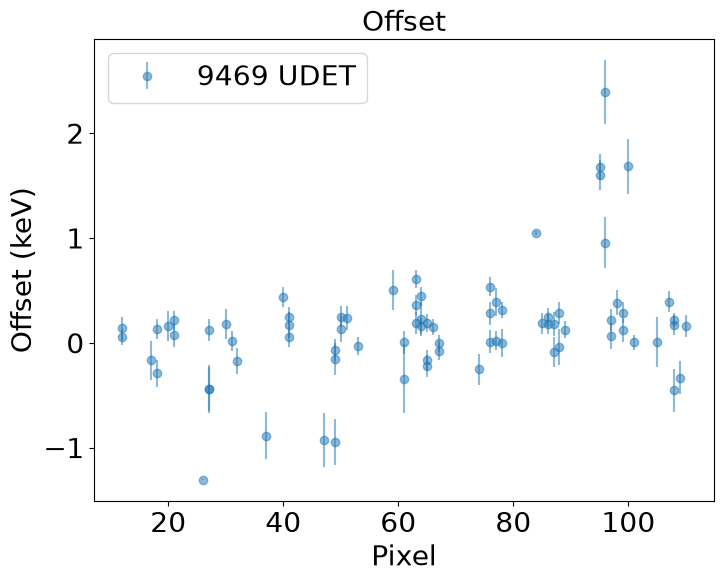

In [19]:
#Here is an example of what you can plot from this dataframe (how I have made lots of plots)

nrows,ncols=1,1
py.figure(figsize=((8)*ncols,(6)*nrows))
ax=py.subplot(nrows,ncols,1)

ax.errorbar(df.pixel, df.constant_kev, yerr=df.constant_error,fmt="o", label="9469 UDET",alpha=0.5)

ax.set_xlabel("Pixel",fontsize=20)
ax.set_ylabel("Offset (keV)",fontsize=20)
ax.legend(fontsize=20)
ax.set_title("Offset",fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=20)
plt.show()

#### Run Overview

In [20]:
#dataframe for all the runs in the database and summary of relevant information to calibrations
q.runs_overview()

,run,hv,start,end,segments,filter_outputs,fits,calibrations
0,8622,-27.000000,2025-10-13 10:22:37-04:00,2025-10-13 11:03:26-04:00,1,414,14,20
1,8623,-27.000000,2025-10-13 11:05:01-04:00,2025-10-13 11:41:26-04:00,1,414,10,16
2,8624,-27.000000,2025-10-13 11:42:35-04:00,2025-10-13 12:12:45-04:00,1,414,11,20
3,8625,-27.000000,2025-10-13 12:14:37-04:00,2025-10-13 12:46:53-04:00,1,414,9,14
4,8626,-27.000000,2025-10-13 12:50:00-04:00,2025-10-13 13:22:03-04:00,1,414,8,10
...,...,...,...,...,...,...,...,...
118,9415,0.000000,2026-08-02 16:13:07-04:00,2026-08-02 22:53:11-04:00,13,2769,78,108
119,9416,0.000000,2026-08-02 23:02:26-04:00,2026-08-03 12:48:52-04:00,4,852,39,48
120,9464,27.043956,2026-08-10 08:30:57-04:00,2026-08-10 13:02:45-04:00,76,16188,0,0
121,9469,27.032112,2026-08-10 18:30:54-04:00,2026-08-11 23:05:23-04:00,54,11502,413,604


#### Fit overview

In [17]:
#dataframe that sumarizes all the first of a list of runs
q.fit_overview([8622])

,run,segment,pixel,detector,tf_label,recipe,reduced_chi2,attempt,window,fit_lo,fit_hi
0,8622,0,60,upper,nabpy-standard,ce-6peak,1.487368,recipe,recipe window,1200,3400
1,8622,0,60,upper,nabpy-standard,auger-2peak,1.530554,recipe,predicted window,28,176
2,8622,0,64,upper,nabpy-standard,ce-6peak,1.278184,fill-in 4/6 found,recipe window,1200,3400
3,8622,0,64,upper,nabpy-standard,auger-2peak,1.314141,"fill-in 1/2 found, widths: measured",predicted window,25,174
4,8622,0,76,upper,nabpy-standard,ce-6peak,1.413074,predicted-start,recipe window,1200,3400
5,8622,0,80,upper,nabpy-standard,ce-6peak,1.285586,predicted-start-conditioned,recipe window,1200,3400
6,8622,0,109,upper,nabpy-standard,ce-6peak,1.373842,widths: measured,recipe window,1200,3400
7,8622,0,1048,lower,short-trap-Fall2025,ce-6peak,2.153934,predicted-start-conditioned,recipe window,1200,3400
8,8622,0,1048,lower,short-trap-Fall2025,auger-2peak,1.121047,recipe,recipe window,100,250
9,8622,0,1052,lower,short-trap-Fall2025,ce-6peak,2.233416,predicted-start-conditioned,recipe window,1200,3400


#### Fit parameters

In [117]:
#gives dict of the fitted fit parameters for a particular run,pixel,segment from a spectrum fit
#note it also provides a few extra details from the fit
q.fit_parameters(8622, 60)

{'parameters':     parameter         value      error
 0        amp1  3.379128e+02   7.533001
 1        amp2  8.130767e+01   3.660838
 2        amp3  1.938539e+01   4.332417
 3        amp4  1.284973e+03  13.919989
 4        amp5  3.020575e+02   6.501126
 5        amp6  7.864777e+01   5.484613
 6        beta  1.403373e+01   0.311989
 7        cen1  1.379789e+03   0.111833
 8        cen2  1.600837e+03   0.287560
 9        cen3  1.638281e+03   1.462471
 10       cen4  2.885226e+03   0.061041
 11       cen5  3.105769e+03   0.128732
 12       cen6  3.143842e+03   0.484358
 13         h1  2.888290e-03   0.000521
 14         h2  1.855979e-10   0.001052
 15         h3  3.895457e-02   0.119243
 16         h4  1.152072e-04   0.000071
 17         h5  1.914137e-09   0.008533
 18         h6  7.265244e-03   0.032803
 19  intercept  7.589061e+00   0.614515
 20         n1  1.576193e-01   0.009712
 21         n2  1.554718e-01   0.024440
 22         n3  1.379011e-01   0.395417
 23         n4  1.588036e-

#### Gain map

In [32]:
#df of gain, indended to provide which pixels are low gain through the gain_ratio which compared the calibration gain to the nominal gain
q.gain_map(run_numbers=[9469])

,run,segment,pixel,detector,tf_label,gain_ratio
0,9469,17,108,upper,nabpy-standard,0.989831
1,9469,33,20,upper,nabpy-standard,1.016156
2,9469,30,65,upper,nabpy-standard,1.005872
3,9469,30,108,upper,nabpy-standard,0.989622
4,9469,33,50,upper,nabpy-standard,0.973225
...,...,...,...,...,...,...
292,9469,0,1051,lower,nabpy-standard,0.985196
293,9469,0,1067,lower,nabpy-standard,0.996499
294,9469,0,1096,lower,nabpy-standard,0.990975
295,9469,0,1099,lower,nabpy-standard,0.985143


#### Example use of the low gain map

In [40]:
gain_ratio_values = q.gain_map(run_numbers=[9469]).gain_ratio.values
pixels = q.gain_map(run_numbers=[9469]).pixel.values
low_gain_mask = gain_ratio_values<0.8
low_gain_values = gain_ratio_values[low_gain_mask]
low_gain_pixels = pixels[low_gain_mask]

[print("Pixel %d: gain_ratio = %.2f"%(low_gain_pixels[i],low_gain_values[i])) for i in range(len(low_gain_pixels))]

Pixel 96: gain_ratio = 0.42
Pixel 95: gain_ratio = 0.44
Pixel 95: gain_ratio = 0.44
Pixel 96: gain_ratio = 0.42
Pixel 100: gain_ratio = 0.39


[None, None, None, None, None]

#### Spectrum

In [50]:
#returns bins and histogram counts used for plotting, the default bins are 1 ADC bins from 0 to 4500
bins, counts = q.spectrum(8622, 60, segment=0)

#### Example plot of sepctrum

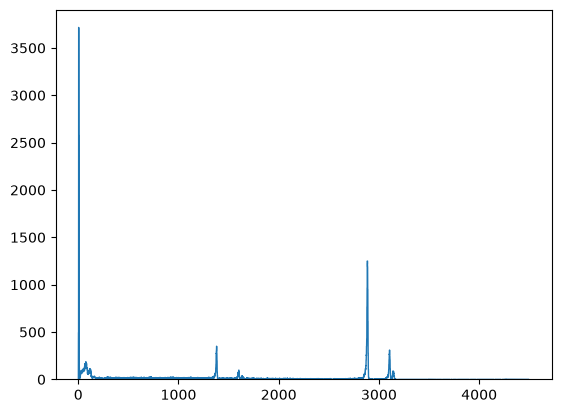

In [51]:
plt.stairs(counts, bins)
plt.show()

#### Raw energies

In [119]:
#returns array of the raw energies from a particular trap filter output
q.raw_energies(8622, 60)

array([ -5.00147608, 705.86900944,  -7.4706939 , ...,   5.50011752,
        50.35571581, 400.68216677])

#### Stored fit

In [59]:
#returns bins and evaluated fit result from the spectrum fits
fit_bins_CE, fit_CE = q.stored_fit_curve(8622, 60)
fit_bins_auger, fit_auger = q.stored_fit_curve(8622, 60,recipe="auger-2peak")

#### Example plots of stored fit

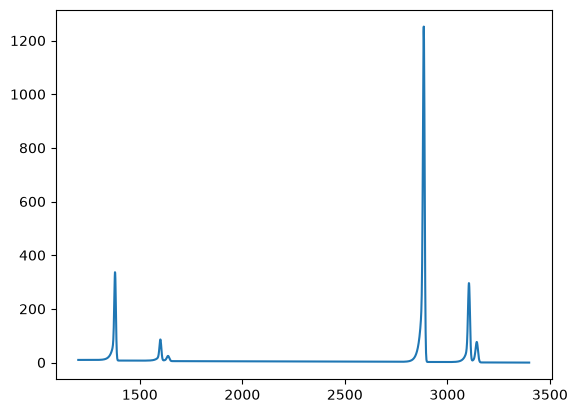

In [60]:
#plot evaluated fit result by itself
plt.plot(fit_bins_CE,fit_CE)
plt.show()

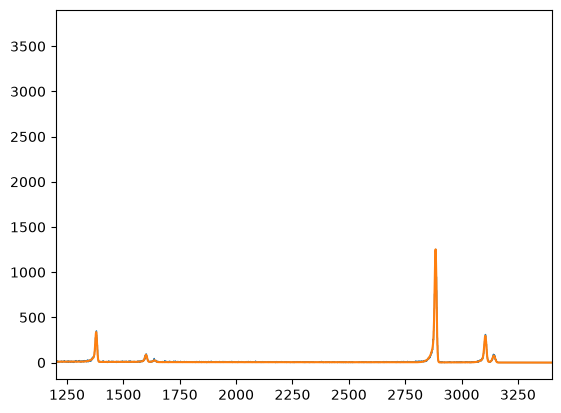

In [61]:
#overlay evaluated fit result with spectra, conversion electron fit example
plt.stairs(counts, bins)
plt.plot(fit_bins_CE,fit_CE)
plt.xlim(1200,3400)
plt.show()

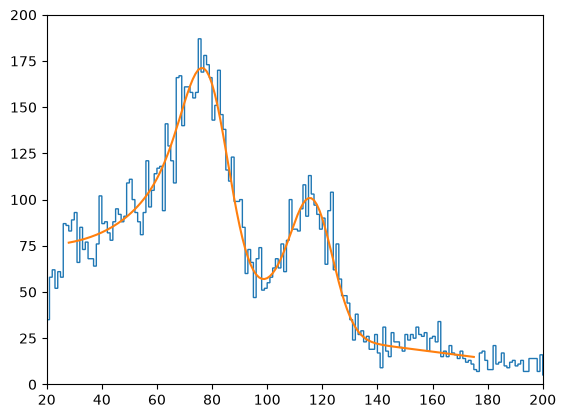

In [68]:
#overlay evaluated fit result with spectra, Auger fit example
plt.stairs(counts, bins)
plt.plot(fit_bins_auger,fit_auger)
plt.xlim(20,200)
plt.ylim(0,200)
plt.show()

#### Centroid trend

In [73]:
#dataframe with centroid trend for particular pixel (tracks through all runs in the database)
df = q.centroid_trend(64, 'CE 976')
df

,run,segment,start,hv,centroid_adc,centroid_error_adc
0,8622,0,2025-10-13 10:22:37-04:00,-27.000000,2900.147560,0.250341
1,8649,0,2025-10-14 12:51:06-04:00,-27.000000,2899.254663,0.102197
2,8713,0,2025-10-21 17:37:58-04:00,-27.000000,2899.319217,0.133540
3,8716,0,2025-10-22 10:06:27-04:00,-27.000000,2899.472749,0.132160
4,8845,0,2025-10-30 14:02:02-04:00,-27.000000,2899.360003,0.123522
5,9469,7,2026-08-10 18:30:54-04:00,27.032112,2899.452363,0.091151
6,9469,37,2026-08-10 18:30:54-04:00,27.032112,2899.915716,0.080279
7,9469,51,2026-08-10 18:30:54-04:00,27.032112,2900.157021,0.146728


#### Example plots using centroid trend

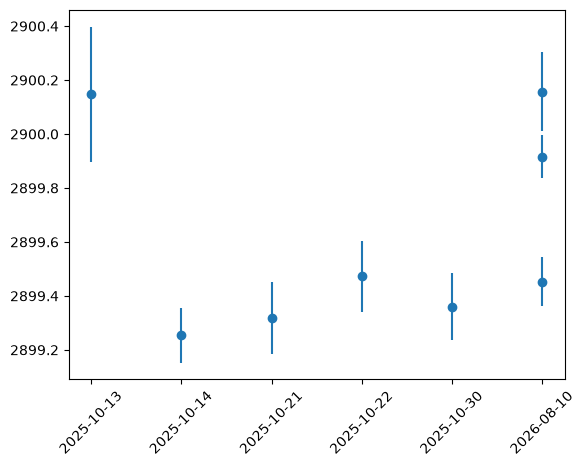

In [107]:
date_strings = [date.astype('datetime64[D]').astype(str) for date in df.start.values]

plt.errorbar(date_strings,df.centroid_adc.values,yerr=df.centroid_error_adc.values,fmt='o')
plt.tick_params(axis='x', labelrotation=45)
plt.ticklabel_format(axis='y', useOffset=False)
plt.show()

#### Calibration points

In [109]:
#dataframe for particular run, pixel with the fitted adc centroids used in a particular calibration
q.calibration_points_table(8622, 60)

,line,adc,adc_error,target_kev,target_error_kev,fitted_kev,residual_kev
0,Auger 56,80.037619,2.499149,25.269661,0.005846,26.379812,1.110151
1,Auger 68,117.260605,3.486520,38.276915,0.002800,38.598471,0.321556
2,CE 482,1379.789315,0.111833,453.020179,0.003731,453.030767,0.010588
3,CE 554,1600.837139,0.287560,525.714534,0.005186,525.590985,-0.123549
4,CE 566,1638.280795,1.462471,538.039124,0.013013,537.882079,-0.157045
5,CE 976,2885.225517,0.061041,947.193705,0.002459,947.198842,0.005137
6,CE 1048,3105.768787,0.128732,1019.613371,0.004933,1019.593437,-0.019934
7,CE 1060,3143.841573,0.484358,1032.008589,0.012757,1032.091047,0.082458


#### Peak table

In [114]:
#dataframe that gives parameters of the peak that was fitted and used in a calibration
#includes centroid, width, and amplitude
q.peak_table(8622, 60, segment=0)

,recipe,line,centroid_adc,centroid_error_adc,sigma_adc,sigma_error_adc,amplitude,amplitude_error
0,auger-2peak,Auger 56,80.037619,2.499149,7.825993,2.124989,124.763014,6.865702
1,auger-2peak,Auger 68,117.260605,3.486520,7.277989,1.269262,79.664343,66.624375
2,ce-6peak,CE 482,1379.789315,0.111833,3.798994,0.080631,337.912783,7.533001
3,ce-6peak,CE 554,1600.837139,0.287560,4.474895,0.258738,81.307670,3.660838
4,ce-6peak,CE 566,1638.280795,1.462471,5.774623,0.869576,19.385389,4.332417
5,ce-6peak,CE 976,2885.225517,0.061041,4.071683,0.040274,1284.973344,13.919989
6,ce-6peak,CE 1048,3105.768787,0.128732,4.673786,0.109155,302.057514,6.501126
7,ce-6peak,CE 1060,3143.841573,0.484358,5.659729,0.264883,78.647772,5.484613


#### Source map

In [111]:
#datafram for particular run, segment that shows which physical source was assigned to each pixel. 
#If there are issues then the source assignment csv has to be updated and reseeded
q.source_map(8622, segment=0)

,pixel,detector,isotope,source
0,48,upper,Bi-207,Bi-207-9176
1,60,upper,Bi-207,Bi-207-9176
2,61,upper,Bi-207,Bi-207-9176
3,63,upper,Bi-207,Bi-207-9177
4,64,upper,Bi-207,Bi-207-9177
5,67,upper,Bi-207,Bi-207-8779
6,68,upper,Bi-207,Bi-207-8779
7,72,upper,Bi-207,Bi-207-9176
8,73,upper,Bi-207,Bi-207-9176
9,76,upper,Bi-207,Bi-207-9177
